## **Librerias Importadas**

In [12]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
#from pandas.tools.plotting import scatter_matrix
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
import string
import math
import sys
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import sklearn
from IPython.core.interactiveshell import InteractiveShell
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


InteractiveShell.ast_node_interactivity = "all"

## **Análisis de los Datos**

In [5]:
df_beans = pd.read_excel("./Dry_Bean_Dataset.xlsx", names = ["Area","Perimeter","MajorAxisLength", "MinorAxisLength", "AspectRation", "Eccentricity", "ConvexArea", "EquivDiameter", "Extent", "Solidity", "roundness", "Compactness", "ShapeFactor1", "ShapeFactor2", "ShapeFactor3", "ShapeFactor4", "class"])
df_beans.head()
df_beans.info()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  class            13611 non-null  object 
dtypes: float64(1

In [ ]:
df_beans.count()
print(df_beans.duplicated())

,0
Area,13611
Perimeter,13611
MajorAxisLength,13611
MinorAxisLength,13611
AspectRation,13611
Eccentricity,13611
ConvexArea,13611
EquivDiameter,13611
Extent,13611
Solidity,13611


0        False
1        False
2        False
3        False
4        False
         ...  
13606    False
13607    False
13608    False
13609    False
13610    False
Length: 13611, dtype: bool


<Figure size 1000x300 with 0 Axes>

<Axes: xlabel='class', ylabel='count'>

Text(0.5, 1.0, 'Distribución de Datos por Clases')

Text(0.5, 0, 'Clases')

Text(0, 0.5, 'Cantidad')

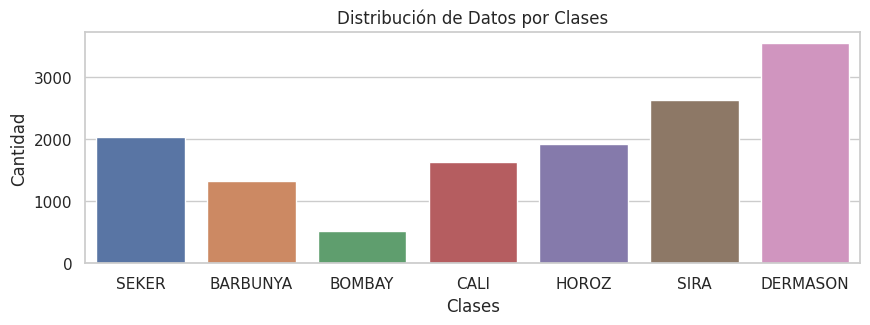

In [ ]:
plt.figure(figsize=(10, 3))
sns.countplot(data=df_beans, x='class', hue='class', legend=False)
plt.title('Distribución de Datos por Clases')
plt.xlabel('Clases')
plt.ylabel('Cantidad')
plt.show()

<Axes: >

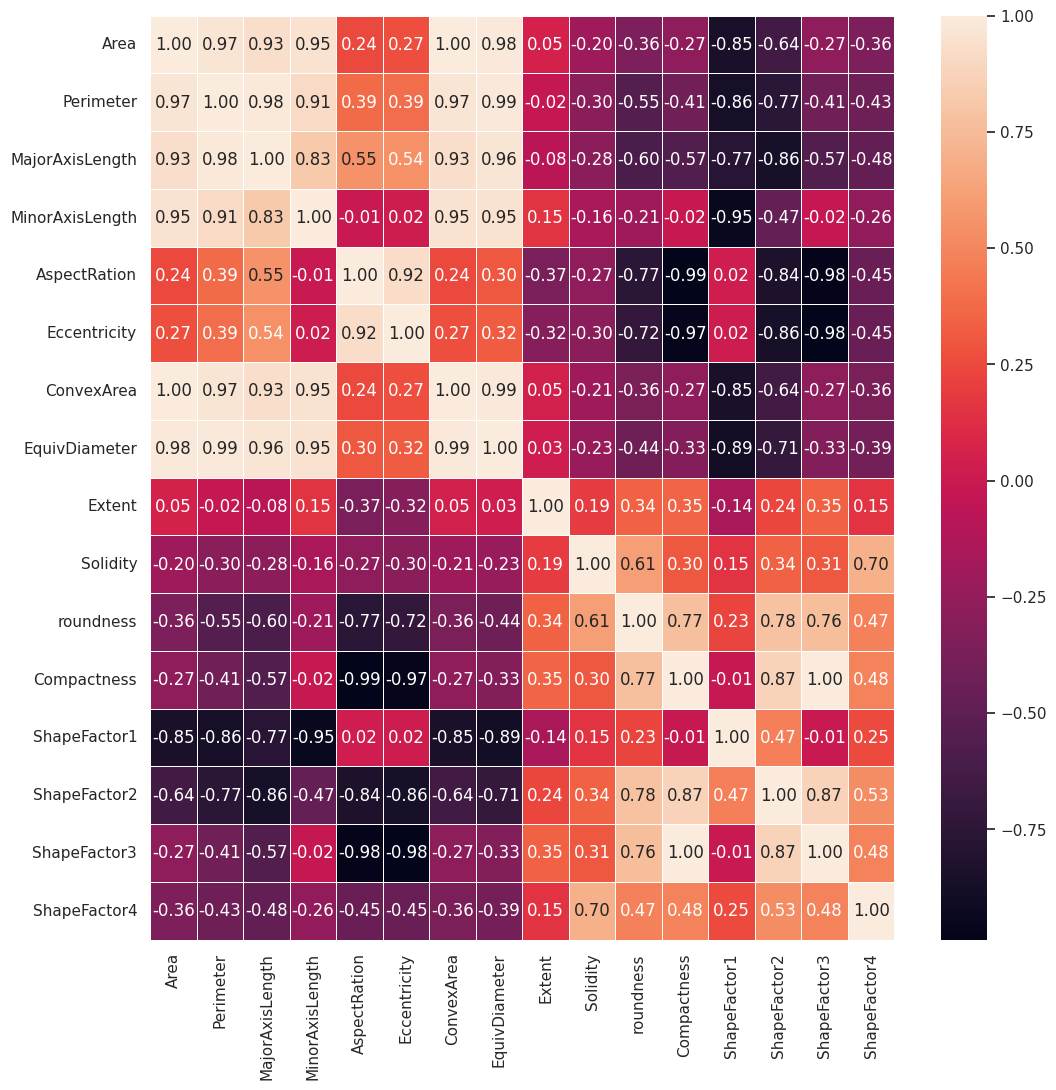

In [ ]:
#df_filt = df_beans.drop(columns=["Perimeter",
#        "MajorAxisLength",
#        "MinorAxisLength",
#        "ConvexArea",
#        "EquivDiameter",
#        "Compactness",
#        "ShapeFactor3",])
df_filt = df_beans.drop(columns=["Perimeter",
        "MajorAxisLength",
        "MinorAxisLength",
        "ConvexArea",
        "EquivDiameter",
        "ShapeFactor3",])
f,ax = plt.subplots(figsize=(12, 12))
sns.heatmap(df_beans.corr(numeric_only=True), annot=True, linewidths=0.5, fmt='.2f',ax=ax)


## **Separación de los Datos (Split)**

In [22]:
x = df_beans.drop(columns=['class'])
y_raw = df_beans['class']

le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
target_names = le.classes_.tolist()

x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded, train_size=0.8, test_size=0.2, random_state=67,
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

print(f"Número de características (dimensiones): {len(x.columns)}")
print(f"Variedades de frijoles a clasificar ({len(target_names)}): {target_names}")
print(f"Forma de x_train_scaled: {x_train_scaled.shape}")
print(f"Forma de y_train_encoded: {y_train_encoded.shape}")
print(f"Primer elemento en el one-hot encoded training set:\n{x_train_scaled[:1]}")
print(f"Primer acierto en el one-hot encoded training set:\n{y_train_encoded[:1]}")

Número de características (dimensiones): 16
Variedades de frijoles a clasificar (7): ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Forma de x_train_scaled: (10888, 16)
Forma de y_train_encoded: (10888, 7)
Primer elemento en el one-hot encoded training set:
[[ 0.66663717  0.95373382  1.22222739  0.36717264  1.45306885  1.15699275
   0.66686706  0.86043415  0.59599816 -0.24013772 -1.02367746 -1.36830683
  -0.62707645 -1.29136846 -1.33121124 -0.25928392]]
Primer acierto en el one-hot encoded training set:
[[0. 0. 1. 0. 0. 0. 0.]]


## **Modelo (One Hot Encoding)**

In [7]:

model = keras.Sequential([
    layers.Input(shape=(x_train_scaled.shape[1],)),
    layers.Dense(12, activation='relu', name='hidden_layer_1'),
    layers.Dense(3, activation='relu', name='hidden_layer_2'),
    layers.Dense(y_train_encoded.shape[1], activation='softmax', name='output_layer')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 3)              │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │            28 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

## **Entrenamiento**

In [8]:
history = model.fit(
    x_train_scaled, y_train_encoded,
    epochs=20,
    batch_size=8,
    validation_split=0.2,
)

Epoch 1/20
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5922 - loss: 0.9752 - val_accuracy: 0.7718 - val_loss: 0.5668
Epoch 2/20
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8251 - loss: 0.4642 - val_accuracy: 0.8802 - val_loss: 0.3818
Epoch 3/20
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8882 - loss: 0.3375 - val_accuracy: 0.8999 - val_loss: 0.3234
Epoch 4/20
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9016 - loss: 0.2987 - val_accuracy: 0.9059 - val_loss: 0.2947
Epoch 5/20
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9098 - loss: 0.2762 - val_accuracy: 0.9160 - val_loss: 0.2742
Epoch 6/20
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9139 - loss: 0.2620 - val_accuracy: 0.9174 - val_loss: 0.2659
Epoch 7/20
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9150 - loss: 0.2514 - val_accuracy: 0.9197 - val_loss: 0.2564
Epoch 8/20
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9163 - loss: 0.2435 - 

## **Test**

In [9]:
predictions = model.predict(x_test_scaled)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test_encoded, axis=1)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## **Matriz de confusión**

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'BARBUNYA'),
  Text(1, 0, 'BOMBAY'),
  Text(2, 0, 'CALI'),
  Text(3, 0, 'DERMASON'),
  Text(4, 0, 'HOROZ'),
  Text(5, 0, 'SIRA'),
  Text(6, 0, 'SIRA')])

Text(0.5, 1.0, 'Matriz de Confusión')

Text(0.5, 0, 'Predicciones')

Text(0, 0.5, 'Valores Verdaderos')

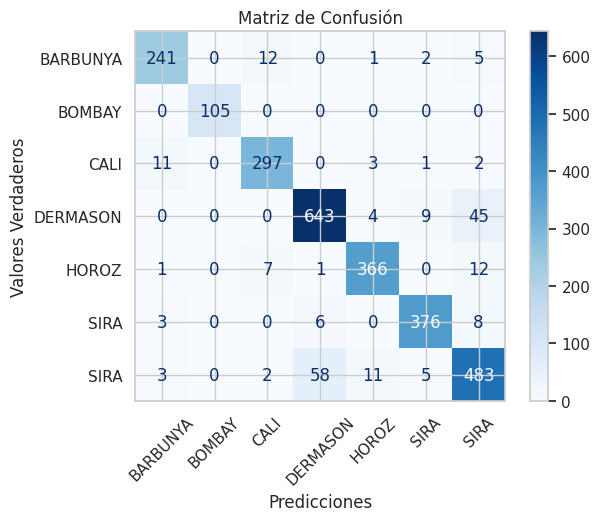

In [21]:
labels = ['BARBUNYA','BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SIRA', 'SIRA']
confusion_matrix_model = confusion_matrix(true_classes, predicted_classes)
display_matrix = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_model, display_labels=labels)
display_matrix.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.show()